In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, silhouette_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('netflix_featured.csv')
print(df.shape)

(8783, 23)


cleaning genres to standardize it like Comedies TV Comedies & Comedy, Drama, Documentary etc.

In [4]:
df['primary_genre'].unique()

array(['Documentaries', 'International TV Shows', 'Crime TV Shows',
       'Docuseries', 'TV Dramas', 'Children & Family Movies', 'Dramas',
       'British TV Shows', 'Comedies', 'TV Comedies', 'Thrillers',
       'Horror Movies', "Kids' TV", 'Action & Adventure', 'Reality TV',
       'Anime Series', 'International Movies', 'Sci-Fi & Fantasy',
       'Classic Movies', 'TV Shows', 'Stand-Up Comedy',
       'TV Action & Adventure', 'Movies', 'Stand-Up Comedy & Talk Shows',
       'Classic & Cult TV', 'Anime Features', 'Romantic TV Shows',
       'Cult Movies', 'Independent Movies', 'TV Horror',
       'Spanish-Language TV Shows', 'Music & Musicals', 'Romantic Movies',
       'LGBTQ Movies', 'TV Sci-Fi & Fantasy', 'Sports Movies'],
      dtype=object)

In [7]:
genre_map = {
    'Comedies':'Comedy', 'TV Comedies':'Comedy',
    'Dramas':'Drama', 'TV Dramas':'Drama',
    'Action & Adventure':'Action', 'TV Action & Adventure':'Action',
    'Crime TV Shows':'Crime',
    'Horror Movies':'Horror', 'TV Horror':'Horror',
    'Documentaries':'Documentary', 'Docuseries':'Documentary',
    'International TV Shows':'International', 'International Movies':'International',
    'Children & Family Movies':'Kids/Family', "Kids' TV":'Kids/Family',
    'Anime Features':'Anime', 'Anime Series':'Anime',
    'Stand-Up Comedy':'Stand-Up', 'Stand-Up Comedy & Talk Shows':'Stand-Up',
    'Reality TV':'Reality',
    'Romantic Movies':'Romance', 'Romantic TV Shows':'Romance',
    'Sci-Fi & Fantasy':'Sci-Fi', 'TV Sci-Fi & Fantasy':'Sci-Fi',
    'British TV Shows':'Regional', 'Spanish-Language TV Shows':'Regional',
    'Classic Movies':'Classic', 'Classic & Cult TV':'Classic',
    'Cult Movies':'Specialty', 'Music & Musicals':'Music',
    'Independent Movies':'Independent', 'Sports Movies':'Sports',
    'LGBTQ Movies':'LGBTQ', 'Thrillers':'Thriller',
    'Movies':'Other', 'TV Shows':'Other',
}
df['genre_clean'] = df['primary_genre'].map(genre_map).fillna('Other')
print(df['genre_clean'].value_counts())

genre_clean
Drama            1667
Comedy           1325
Documentary      1048
Kids/Family       989
International     899
Action            897
Crime             397
Stand-Up          367
Horror            286
Regional          254
Anime             196
Reality           119
Classic           100
Other              73
Thriller           65
Romance            35
Independent        20
Music              18
Sci-Fi             14
Specialty          12
LGBTQ               1
Sports              1
Name: count, dtype: int64


In [8]:
# Preprocessing for Classification

CLF_FEATURES = ['genre_clean','rating','primary_country',
                'content_recency','release_year','year_added',
                'content_age','month_added']

df_clf = df[CLF_FEATURES + ['type']].copy()
df_clf['primary_country'] = df_clf['primary_country'].fillna('Unknown')

In [9]:
for col in ['genre_clean','rating','primary_country','content_recency']:
    le = LabelEncoder()
    df_clf[col] = le.fit_transform(df_clf[col].astype(str))

scaler = StandardScaler()
df_clf[['release_year','year_added','content_age','month_added']] = scaler.fit_transform(
    df_clf[['release_year','year_added','content_age','month_added']])

X_clf = df_clf[CLF_FEATURES].values
y = (df['type'] == 'movie').astype(int)

In [10]:
print(f"Shape: {X_clf.shape}")
print(f"Movie: {y.sum()} | TV Show: {(1-y).sum()}")

Shape: (8783, 8)
Movie: 6129 | TV Show: 2654


Random Forest Model

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_clf, y, cv=cv, scoring='accuracy')

print(f"CV Accuracy: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")

CV Accuracy: 89.07% ± 0.76%


In [12]:
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(classification_report(y_test, y_pred, target_names=['TV Show','Movie']))

Test Accuracy: 89.93%
              precision    recall  f1-score   support

     TV Show       0.84      0.82      0.83       531
       Movie       0.92      0.93      0.93      1226

    accuracy                           0.90      1757
   macro avg       0.88      0.88      0.88      1757
weighted avg       0.90      0.90      0.90      1757



##### Confusion matrix of RandomForest Classifier

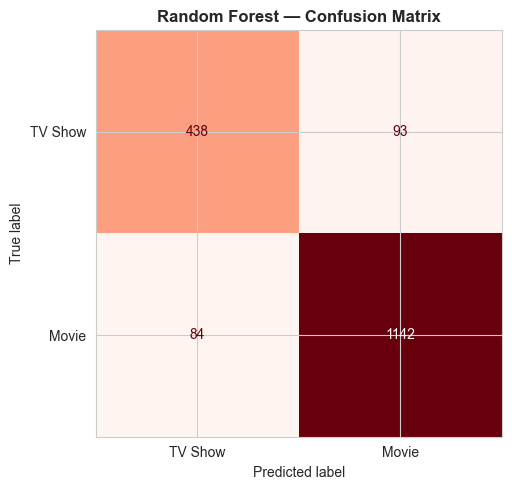

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=['TV Show','Movie']).plot(ax=ax, cmap='Reds', colorbar=False)
ax.set_title('Random Forest — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

##### Feature Importance

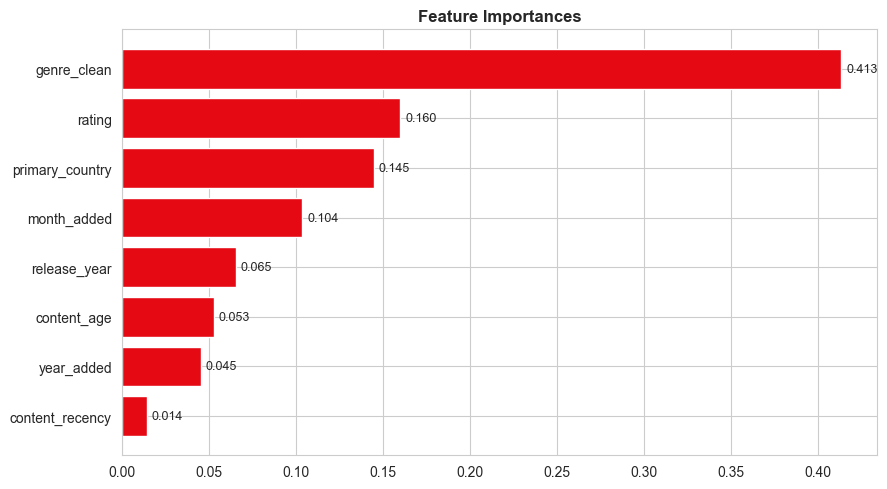

In [14]:
feat_df = pd.DataFrame({'Feature': CLF_FEATURES,
                        'Importance': rf.feature_importances_}
                       ).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(feat_df['Feature'], feat_df['Importance'], color='#E50914', edgecolor='white')
ax.set_title('Feature Importances', fontweight='bold')
for i, v in enumerate(feat_df['Importance']):
    ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

Preprocessing for Clustering

In [15]:
CLUSTER_FEATURES = ['genre_clean','rating','primary_country','content_recency',
                    'release_year','year_added','content_age','month_added',
                    'movie_minutes','tv_seasons']

df_clust = df[CLUSTER_FEATURES].copy()
df_clust['primary_country'] = df_clust['primary_country'].fillna('Unknown')
df_clust['movie_minutes']   = df_clust['movie_minutes'].fillna(0)
df_clust['tv_seasons']      = df_clust['tv_seasons'].fillna(0)

In [16]:
for col in ['genre_clean','rating','primary_country','content_recency']:
    le = LabelEncoder()
    df_clust[col] = le.fit_transform(df_clust[col].astype(str))

X_clust = StandardScaler().fit_transform(df_clust[CLUSTER_FEATURES].values)
print(f"Shape: {X_clust.shape}")

Shape: (8783, 10)


Elbow Method to find appropriate K-Cluster 

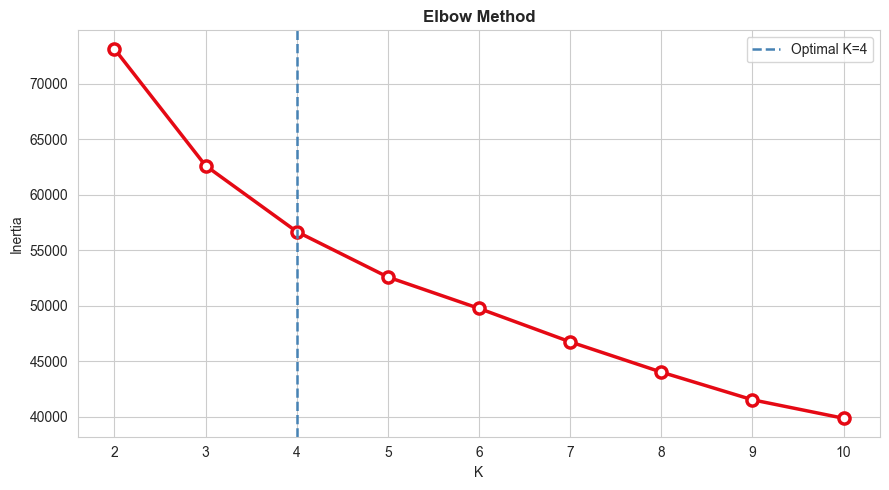

In [19]:
inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(2,11), inertias, marker='o', color='#E50914',
        linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2.5)
ax.axvline(x=4, color='steelblue', linestyle='--', linewidth=1.8, label='Optimal K=4')
ax.set_xlabel('K'); ax.set_ylabel('Inertia')
ax.set_title('Elbow Method', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

KMeans Clustering

In [20]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_clust)

silhouette score measuring how well each point fits its own cluster vs neighbouring clusters. Score ranges from -1 to 1. closer to 1 means clusters are well separated.

In [21]:
score = silhouette_score(X_clust, df['cluster'])
print(f"Silhouette Score: {score:.4f}")
print(df['cluster'].value_counts().sort_index())

Silhouette Score: 0.1519
cluster
0    3111
1    2536
2    2634
3     502
Name: count, dtype: int64


PCA Visualization

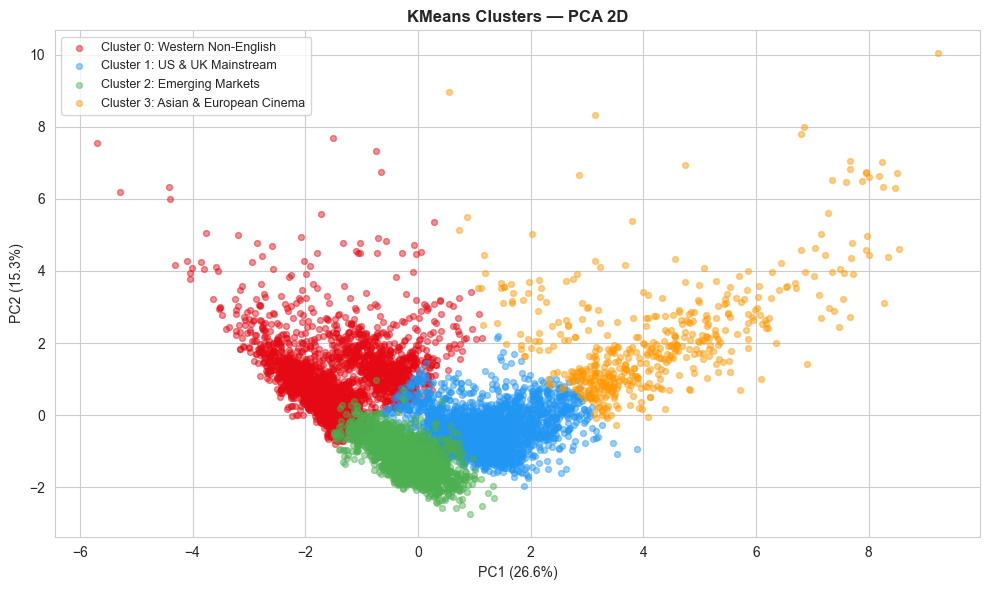

In [22]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust)
explained = pca.explained_variance_ratio_ * 100

colors = ['#E50914','#2196F3','#4CAF50','#FF9800']
labels = ['Cluster 0: Western Non-English','Cluster 1: US & UK Mainstream',
          'Cluster 2: Emerging Markets','Cluster 3: Asian & European Cinema']

fig, ax = plt.subplots(figsize=(10, 6))
for c in range(4):
    mask = df['cluster'] == c
    ax.scatter(X_pca[mask,0], X_pca[mask,1], c=colors[c], label=labels[c], alpha=0.45, s=18)
ax.set_xlabel(f'PC1 ({explained[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]:.1f}%)')
ax.set_title('KMeans Clusters — PCA 2D', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Cluster Profiles

In [23]:
cluster_labels = {0:'Western Non-English', 1:'US & UK Mainstream',
                  2:'Emerging Markets', 3:'Asian & European Cinema'}

for c in range(4):
    sub = df[df['cluster']==c]
    print(f"\nCluster {c} — {cluster_labels[c]} (n={len(sub):,})")
    print(f"  Type           : {sub['type'].value_counts().to_dict()}")
    print(f"  Top Genres     : {sub['genre_clean'].value_counts().head(3).index.tolist()}")
    print(f"  Top Countries  : {sub['primary_country'].value_counts().head(3).index.tolist()}")
    print(f"  Top Ratings    : {sub['rating'].value_counts().head(3).index.tolist()}")
    print(f"  Avg Movie Dur  : {sub['movie_minutes'].mean():.0f} min")
    print(f"  Avg TV Seasons : {sub['tv_seasons'].mean():.1f}")
    print(f"  Avg Content Age: {sub['content_age'].mean():.1f} yrs")


Cluster 0 — Western Non-English (n=3,111)
  Type           : {'tv_show': 2542, 'movie': 569}
  Top Genres     : ['International', 'Kids/Family', 'Crime']
  Top Countries  : ['United States', 'Unknown', 'United Kingdom']
  Top Ratings    : ['TV-MA', 'TV-14', 'TV-PG']
  Avg Movie Dur  : 58 min
  Avg TV Seasons : 1.8
  Avg Content Age: 1.8 yrs

Cluster 1 — US & UK Mainstream (n=2,536)
  Type           : {'movie': 2466, 'tv_show': 70}
  Top Genres     : ['Drama', 'Comedy', 'Action']
  Top Countries  : ['United States', 'India', 'United Kingdom']
  Top Ratings    : ['TV-14', 'TV-MA', 'R']
  Avg Movie Dur  : 107 min
  Avg TV Seasons : 1.1
  Avg Content Age: 6.9 yrs

Cluster 2 — Emerging Markets (n=2,634)
  Type           : {'movie': 2620, 'tv_show': 14}
  Top Genres     : ['Drama', 'Documentary', 'Comedy']
  Top Countries  : ['United States', 'India', 'Unknown']
  Top Ratings    : ['TV-MA', 'TV-14', 'TV-PG']
  Avg Movie Dur  : 99 min
  Avg TV Seasons : 1.0
  Avg Content Age: 0.4 yrs

Cluste

Genre per Cluster Plot

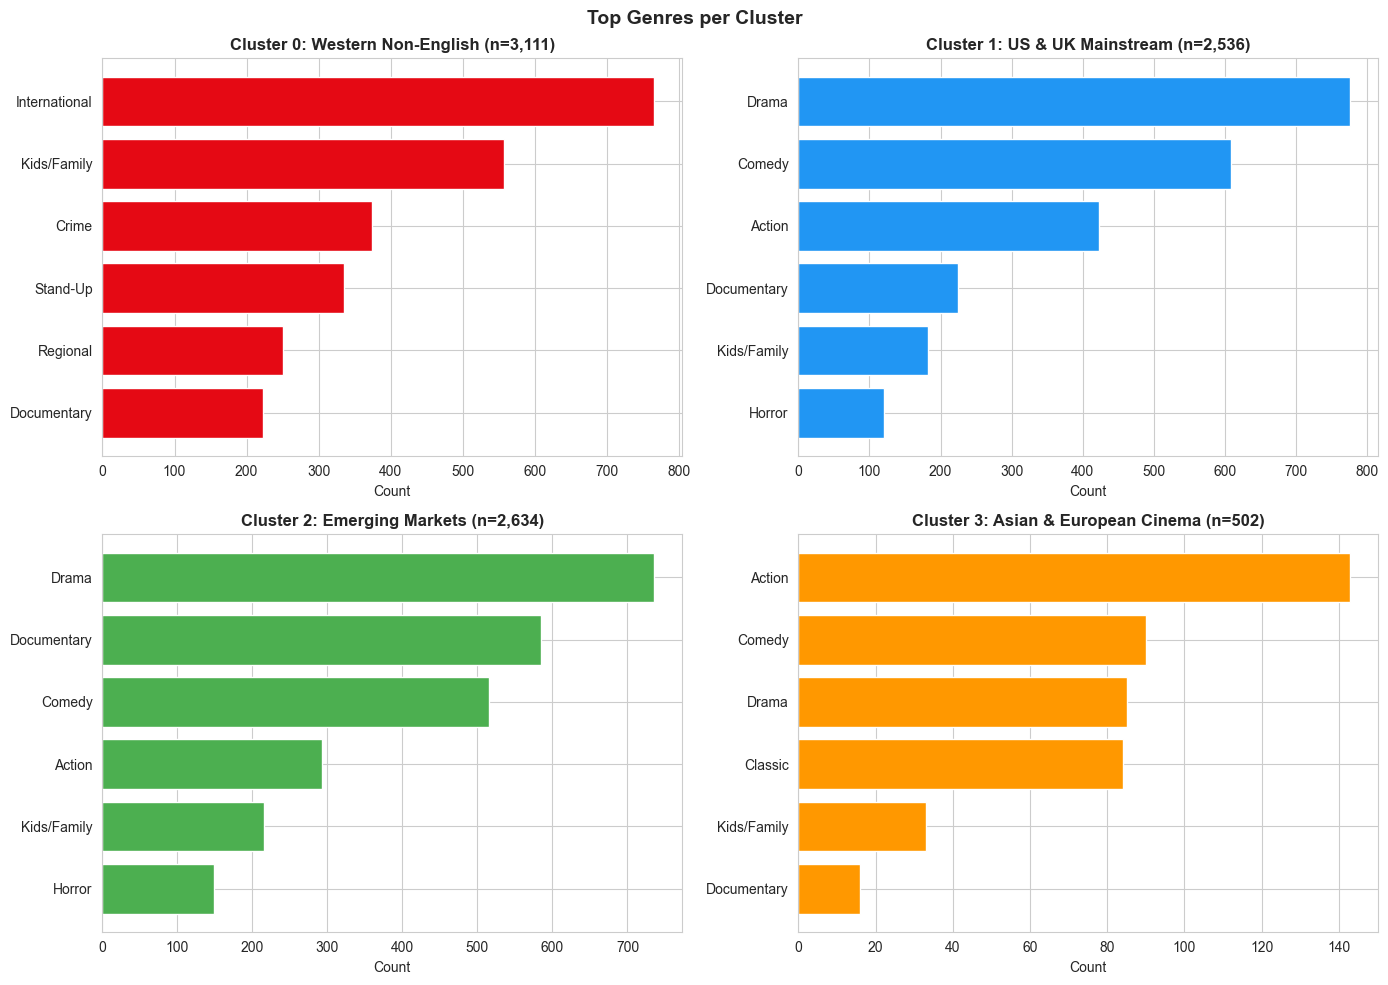

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['#E50914','#2196F3','#4CAF50','#FF9800']

for idx, (ax, c) in enumerate(zip(axes.flat, range(4))):
    sub = df[df['cluster']==c]
    gc  = sub['genre_clean'].value_counts().head(6)
    ax.barh(gc.index[::-1], gc.values[::-1], color=colors[idx], edgecolor='white')
    ax.set_title(f'Cluster {c}: {cluster_labels[c]} (n={len(sub):,})', fontweight='bold')
    ax.set_xlabel('Count')

fig.suptitle('Top Genres per Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Genre by Country

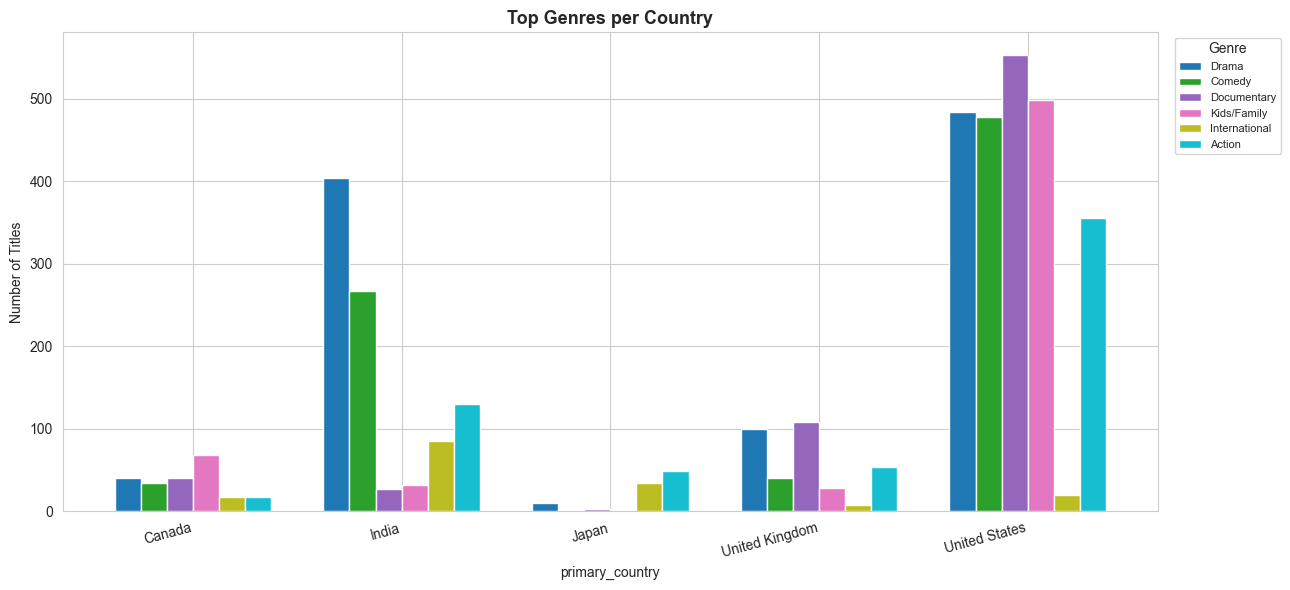

In [26]:
top_countries = [c for c in df['primary_country'].value_counts().head(6).index
                 if c != 'Unknown'][:5]
top_genres = df['genre_clean'].value_counts().head(6).index
pivot = df[df['primary_country'].isin(top_countries)]\
        .groupby(['primary_country','genre_clean']).size().unstack(fill_value=0)[top_genres]

fig, ax = plt.subplots(figsize=(13, 6))
pivot.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white', width=0.75)
ax.set_title('Top Genres per Country', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Titles')
ax.set_xticklabels(pivot.index, rotation=15, ha='right')
ax.legend(title='Genre', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

USA dominates all genres, India heavy on Drama, Japan on Action